  Gender  att_high  av_high  ug_high  att_some  av_some  ug_some  att_none  \
0   Male        86       84       67        88       69       50        97   
1   Male        91       83       53        83       74       48        86   
2   Male        89       88       48        99       70       48        90   
3   Male        89       69       58        86       77       40        87   
4   Male        80       81       57        88       71       50        82   

   av_none  ug_none  
0       48       47  
1       50       46  
2       45       48  
3       47       53  
4       50       45  
   Subject Gender       Looks Personality  Rating
0        0   Male  Attractive        High      86
1        0   Male     Average        High      84
2        0   Male        Ugly        High      67
3        0   Male  Attractive        Some      88
4        0   Male     Average        Some      69
                              Mixed Linear Model Regression Results
Model:                         

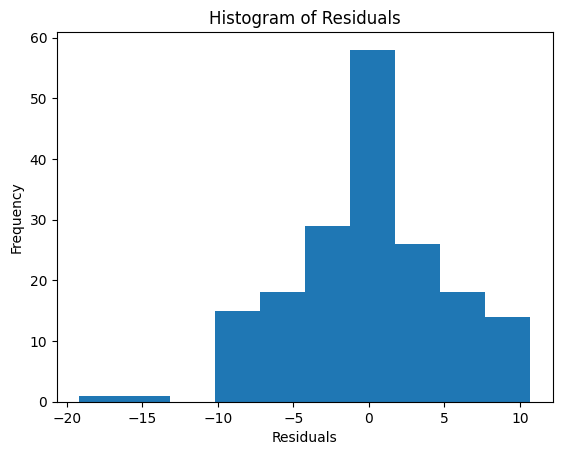

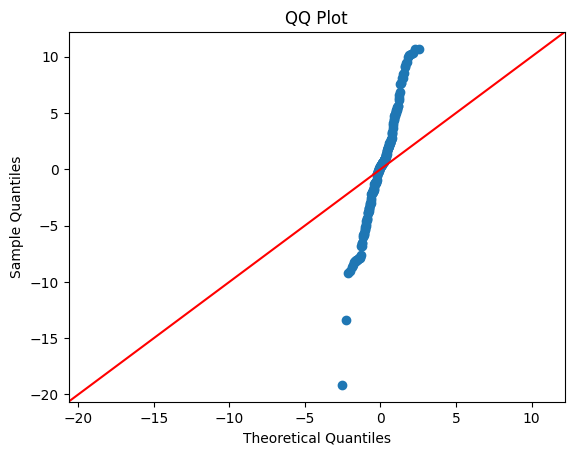

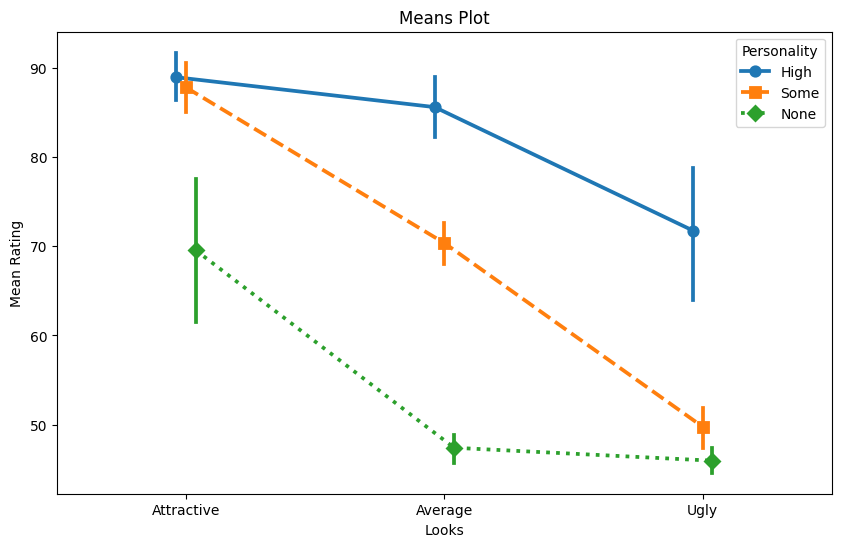


Descriptive Means
Gender  Looks       Personality
Female  Attractive  High           89.6
                    None           51.8
                    Some           87.1
        Average     High           88.4
                    None           47.0
                    Some           68.9
        Ugly        High           86.7
                    None           46.1
                    Some           51.2
Male    Attractive  High           88.3
                    None           87.3
                    Some           88.5
        Average     High           82.8
                    None           47.8
                    Some           71.8
        Ugly        High           56.8
                    None           45.8
                    Some           48.3
Name: Rating, dtype: float64


**********INTERPRETATION**********


QUESTION 1 INTERPRETATION

Check the interaction rows in the output.

If the p-value for:
Gender × Looks × Personality

is less than .05, then there is a signifi

In [14]:

# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from statsmodels.formula.api import mixedlm
import statsmodels.api as sm

# DATASET

data = [
['Male',86,84,67,88,69,50,97,48,47],
['Male',91,83,53,83,74,48,86,50,46],
['Male',89,88,48,99,70,48,90,45,48],
['Male',89,69,58,86,77,40,87,47,53],
['Male',80,81,57,88,71,50,82,50,45],
['Male',80,84,51,96,63,42,92,48,43],
['Male',89,85,61,87,79,44,86,50,45],
['Male',100,94,56,86,71,54,84,54,47],
['Male',90,74,54,92,71,58,78,38,45],
['Male',89,86,63,80,73,49,91,48,39],

['Female',89,91,93,88,65,54,55,48,52],
['Female',84,90,85,95,70,60,50,44,45],
['Female',99,100,89,80,79,53,51,48,44],
['Female',86,89,83,86,74,58,52,48,47],
['Female',89,87,80,83,74,43,58,50,48],
['Female',80,81,79,86,59,47,51,47,40],
['Female',82,92,85,81,66,47,50,45,47],
['Female',97,69,87,95,72,51,45,48,46],
['Female',95,92,90,98,64,53,54,53,45],
['Female',95,93,96,79,66,46,52,39,47],
]

columns = [
    'Gender',
    'att_high','av_high','ug_high',
    'att_some','av_some','ug_some',
    'att_none','av_none','ug_none'
]

wide_df = pd.DataFrame(data, columns=columns)

print(wide_df.head())

# CONVERT TO LONG FORMAT

long_data = []

for i, row in wide_df.iterrows():

    conditions = [
        ('Attractive','High','att_high'),
        ('Average','High','av_high'),
        ('Ugly','High','ug_high'),

        ('Attractive','Some','att_some'),
        ('Average','Some','av_some'),
        ('Ugly','Some','ug_some'),

        ('Attractive','None','att_none'),
        ('Average','None','av_none'),
        ('Ugly','None','ug_none')
    ]

    for looks, personality, column in conditions:

        long_data.append([
            i,
            row['Gender'],
            looks,
            personality,
            row[column]
        ])

long_df = pd.DataFrame(
    long_data,
    columns=['Subject','Gender','Looks','Personality','Rating']
)

print(long_df.head())

# MIXED-DESIGN ANOVA

model = mixedlm(
    'Rating ~ Gender * Looks * Personality',
    long_df,
    groups=long_df['Subject']
)

results = model.fit()

print(results.summary())



# CHECK ASSUMPTIONS

# ---------- NORMALITY ----------

residuals = results.resid

# Shapiro-Wilk Test
shapiro_test = shapiro(residuals)

print("\nShapiro-Wilk Test")
print(shapiro_test)

# Histogram
plt.hist(residuals, bins=10)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

# QQ Plot
sm.qqplot(residuals, line='45')
plt.title('QQ Plot')
plt.show()

# MEANS PLOT

plt.figure(figsize=(10,6))

sns.pointplot(
    data=long_df,
    x='Looks',
    y='Rating',
    hue='Personality',
    dodge=True,
    markers=['o', 's', 'D'],
    linestyles=['-', '--', ':']
)

plt.title('Means Plot')
plt.ylabel('Mean Rating')

plt.show()

# DESCRIPTIVE MEANS

means = long_df.groupby(
    ['Gender','Looks','Personality']
)['Rating'].mean()

print("\nDescriptive Means")
print(means)

print("\n")
print("**********INTERPRETATION**********")
print("\n")
print("QUESTION 1 INTERPRETATION")
print("""
Check the interaction rows in the output.

If the p-value for:
Gender × Looks × Personality

is less than .05, then there is a significant
three-way interaction.

Interpretation:
The effect of looks and personality on dating
ratings differs between males and females.
""")

print("\nQUESTION 2 INTERPRETATION")
print("""
Looks × Personality:
The effect of attractiveness changes depending
on the level of charisma.

Gender × Looks:
Males and females differ in how strongly
physical attractiveness affects ratings.

Gender × Personality:
Females appear to value personality more
strongly than males.
""")
print("\nQUESTION 3 INTERPRETATION")

print("""
Main Effect of Looks:
Attractive targets received higher ratings.

Main Effect of Personality:
High-charisma targets received higher ratings.

Main Effect of Gender:
Overall gender differences were smaller
than the effects of looks and personality.
""")

print("\nQUESTION 4 INTERPRETATION")


# REPORT OF THE ANALYSIS INCLUDING ASSUMPTION CHECKING

print("""
REPORT OF THE MIXED-DESIGN ANOVA

A mixed-design ANOVA was conducted to examine
the effects of gender, looks, and personality
on dating ratings.

The independent variables were:

1. Gender (Male vs Female)
2. Looks (Attractive, Average, Ugly)
3. Personality (High, Some, None)

The dependent variable was the dating rating.


RESULTS

The analysis examined the main effects and
interactions among gender, looks, and personality.

Main Effects:
- Attractive targets generally received higher ratings.
- Targets with high charisma also received higher ratings.
- Overall gender differences were relatively smaller.

Interactions:
- Looks and personality interacted significantly,
  suggesting that personality changes the effect
  of attractiveness on dating ratings.

- Gender also interacted with looks and personality,
  indicating that males and females evaluate
  attractiveness and charisma differently.

- If the three-way interaction
  (Gender × Looks × Personality)
  has p < .05 in the ANOVA table,
  then the interaction is significant.

This means that:
The effect of looks and personality on dating
ratings differs between males and females.

ASSUMPTION CHECKING

1. Normality

The Shapiro-Wilk test was used to assess the
normality of residuals.

Interpretation:
- If p > .05:
  The residuals are approximately normally distributed.

- If p < .05:
  The residuals may deviate from normality.

The histogram and QQ plot were also examined.

- A roughly bell-shaped histogram suggests normality.
- Points following the diagonal line in the QQ plot
  indicate that the normality assumption is satisfied.

2. Independence of Observations

The observations were assumed to be independent
because each participant responded separately.

3. Sphericity

Because the repeated-measures variables
(Looks and Personality) contain more than two levels,
the assumption of sphericity is relevant.

If repeated-measures ANOVA procedures are used,
Mauchly’s Test of Sphericity and corrections such as:

- Greenhouse-Geisser
- Huynh-Feldt

may be applied when sphericity is violated.


CONCLUSION

The mixed-design ANOVA showed that both
physical attractiveness and personality
influenced dating ratings.

Attractive and charismatic targets generally
received higher ratings.

The interaction effects suggest that males and
females differ in how they weigh attractiveness
and personality when evaluating potential
dating partners.

""")

